In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/CAPSTONE_ASL')
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_DIR = PROJECT_ROOT / 'download'
DATA_DIR     = PROJECT_ROOT / 'ASL_Citizen'
KEYPOINT_DIR = PROJECT_ROOT / 'keypoints'

DOWNLOAD_DIR.mkdir(exist_ok=True)
KEYPOINT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
!df -h /content/drive/MyDrive | head -2

Project root: /content/drive/MyDrive/CAPSTONE_ASL
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   21G  206G  10% /


In [ ]:
from pathlib import Path
import os

PROJECT_ROOT = Path('/content/drive/MyDrive/CAPSTONE_ASL')
DOWNLOAD_DIR = PROJECT_ROOT / 'download'
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

zip_path = DOWNLOAD_DIR / 'ASL_Citizen.zip'

if zip_path.exists():
    size_gb = zip_path.stat().st_size / 1e9
    print(f"Already downloaded: {size_gb:.1f} GB")
else:
    print("Downloading (20-40 min)...")
    !wget -c --show-progress -O "{zip_path}" \
        "https://download.microsoft.com/download/b/8/8/b88c0bae-e6c1-43e1-8726-98cf5af36ca4/ASL_Citizen.zip"
    print(f"Downloaded: {zip_path.stat().st_size / 1e9:.1f} GB")

# Force Drive to flush this large write
from google.colab import drive
drive.flush_and_unmount()
print("Drive unmounted — wait 30 seconds, then remount in next cell")

--2026-05-10 20:08:38--  https://download.microsoft.com/download/b/8/8/b88c0bae-e6c1-43e1-8726-98cf5af36ca4/ASL_Citizen.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.217.78.64, 2600:1407:3c00:e9b::317f, 2600:1407:3c00:ea3::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.217.78.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45924134223 (43G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/CAPSTONE_ASL/download/ASL_Citizen.zip’

/content/drive/MyDr 100%[===================>]  42.77G  12.1MB/s    in 83m 26s 

2026-05-10 21:32:05 (8.75 MB/s) - ‘/content/drive/MyDrive/CAPSTONE_ASL/download/ASL_Citizen.zip’ saved [45924134223/45924134223]

Downloaded: 45.9 GB
Drive unmounted — wait 30 seconds, then remount in next cell


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
zip_path = Path('/content/drive/MyDrive/CAPSTONE_ASL/download/ASL_Citizen.zip')
if zip_path.exists():
    print(f"Zip on Drive: {zip_path.stat().st_size / 1e9:.1f} GB ✓")
else:
    print("ZIP NOT FOUND — re-run Step 1")

Mounted at /content/drive
Zip on Drive: 45.9 GB ✓


In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    names = z.namelist()
    print(f"Total entries in zip: {len(names)}")
    print()
    print("First 30 entries:")
    for n in names[:30]:
        print(f"  {n}")
    print()
    print("Top-level structure:")
    top_level = sorted(set(n.split('/')[0] for n in names if n))
    for t in top_level:
        print(f"  {t}/")

Total entries in zip: 83406

First 30 entries:
  ASL_Citizen/
  ASL_Citizen/splits/
  ASL_Citizen/splits/val.csv
  ASL_Citizen/splits/train.csv
  ASL_Citizen/splits/test.csv
  ASL_Citizen/videos/
  ASL_Citizen/videos/5086723486875651-RUN.mp4
  ASL_Citizen/videos/2233415645150214-SWEET.mp4
  ASL_Citizen/videos/09412352698319548-POSSIBLE.mp4
  ASL_Citizen/videos/6184880487426632-PAINT.mp4
  ASL_Citizen/videos/6682045893304822-RACE.mp4
  ASL_Citizen/videos/22425009794174322-SCULPT.mp4
  ASL_Citizen/videos/8563900568328626-SCAR MEMORY.mp4
  ASL_Citizen/videos/6843553981288921-EARTHQUAKE.mp4
  ASL_Citizen/videos/37687322393253075-REPLACE.mp4
  ASL_Citizen/videos/8136380896447564-WRISTWATCH 3.mp4
  ASL_Citizen/videos/023749434963018734-WHISTLE.mp4
  ASL_Citizen/videos/639898672430512-PARTY 2.mp4
  ASL_Citizen/videos/2743155783934501-ELEGANCE.mp4
  ASL_Citizen/videos/11137281856386338-MENTION.mp4
  ASL_Citizen/videos/05931984028494086-NEPHEW.mp4
  ASL_Citizen/videos/23537957976839619-FED UP.m

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    for csv_name in ['ASL_Citizen/splits/train.csv',
                     'ASL_Citizen/splits/val.csv',
                     'ASL_Citizen/splits/test.csv']:
        z.extract(csv_name, path=DATA_DIR.parent)
        out = DATA_DIR.parent / csv_name
        print(f"Extracted: {out.name}  ({out.stat().st_size / 1024:.1f} KB)")

Extracted: train.csv  (1951.7 KB)
Extracted: val.csv  (498.3 KB)
Extracted: test.csv  (1587.9 KB)


In [ ]:
import pandas as pd

train_csv = DATA_DIR / 'splits' / 'train.csv'
val_csv   = DATA_DIR / 'splits' / 'val.csv'
test_csv  = DATA_DIR / 'splits' / 'test.csv'

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print(f"Test:  {len(test_df)} rows")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} rows")
print()
print("Train CSV columns:")
print(train_df.columns.tolist())
print()
print("First 5 rows of train:")
print(train_df.head())

Train: 40154 rows
Val:   10304 rows
Test:  32941 rows
Total: 83399 rows

Train CSV columns:
['Participant ID', 'Video file', 'Gloss', 'ASL-LEX Code']

First 5 rows of train:
  Participant ID                        Video file       Gloss ASL-LEX Code
0             P1       15890366051589533-APPLE.mp4       APPLE     A_03_054
1             P1  35618482303951104-IMPOSSIBLE.mp4  IMPOSSIBLE     B_01_032
2             P1         6958143575951994-PARK.mp4        PARK     E_03_028
3             P1     8006032738002744-SOCCER 2.mp4     SOCCER2     F_03_032
4             P1       37542279833186454-STINK.mp4       STINK     H_01_064


In [ ]:
# What's the gloss/label column called? We'll figure it out from Step 2's output,
# but it's typically 'Gloss' or 'gloss' or 'label'. Let's just look at all column value counts.
for col in train_df.columns:
    n_unique = train_df[col].nunique()
    print(f"  {col}: {n_unique} unique values")

  Participant ID: 35 unique values
  Video file: 40154 unique values
  Gloss: 2731 unique values
  ASL-LEX Code: 2722 unique values


In [ ]:
GLOSS_COL = 'Gloss'

# Class counts in train
class_counts = train_df[GLOSS_COL].value_counts()
print(f"Total classes in train: {len(class_counts)}")
print(f"Class count statistics:")
print(f"  Max:    {class_counts.max()}  ({class_counts.idxmax()})")
print(f"  Median: {class_counts.median():.0f}")
print(f"  Min:    {class_counts.min()}")
print()

top100 = class_counts.head(100)
print(f"Top 100 classes:")
print(f"  Most frequent:  '{top100.index[0]}' with {top100.iloc[0]} samples")
print(f"  100th most:     '{top100.index[-1]}' with {top100.iloc[-1]} samples")
print(f"  Total train samples in top 100: {top100.sum()}")
print()
print("First 20 of the top 100 classes:")
print(top100.head(20))

Total classes in train: 2731
Class count statistics:
  Max:    24  (DOG1)
  Median: 15
  Min:    9

Top 100 classes:
  Most frequent:  'DOG1' with 24 samples
  100th most:     'TAIL1' with 17 samples
  Total train samples in top 100: 1800

First 20 of the top 100 classes:
Gloss
DOG1             24
HURDLE/TRIP1     22
BREAKFAST1       21
DEMAND1          21
DARK1            21
BITE1            21
WHATFOR1         20
DEAF1            20
MECHANIC1        20
PARTY1           20
ROCKINGCHAIR1    20
DECIDE1          20
BEE1             19
BELT1            19
EDIT1            19
ELEVATOR1        19
BASKETBALL1      19
LUNCH1           19
PATIENT2         19
DEVELOP1         19
Name: count, dtype: int64


In [ ]:
train_signers = set(train_df['Participant ID'].unique())
val_signers   = set(val_df['Participant ID'].unique())
test_signers  = set(test_df['Participant ID'].unique())

print(f"Train signers: {len(train_signers)}")
print(f"Val signers:   {len(val_signers)}")
print(f"Test signers:  {len(test_signers)}")
print()
print(f"Train ∩ Val:   {len(train_signers & val_signers)} signers")
print(f"Train ∩ Test:  {len(train_signers & test_signers)} signers")
print(f"Val ∩ Test:    {len(val_signers & test_signers)} signers")

Train signers: 35
Val signers:   6
Test signers:  11

Train ∩ Val:   0 signers
Train ∩ Test:  0 signers
Val ∩ Test:    0 signers


In [ ]:
top100_classes = set(top100.index)

# Filter each split to just our top-100 classes
sub_train = train_df[train_df[GLOSS_COL].isin(top100_classes)].reset_index(drop=True)
sub_val   = val_df[val_df[GLOSS_COL].isin(top100_classes)].reset_index(drop=True)
sub_test  = test_df[test_df[GLOSS_COL].isin(top100_classes)].reset_index(drop=True)

print(f"Subset sizes:")
print(f"  Train: {len(sub_train)} videos  ({sub_train[GLOSS_COL].nunique()} classes)")
print(f"  Val:   {len(sub_val)} videos  ({sub_val[GLOSS_COL].nunique()} classes)")
print(f"  Test:  {len(sub_test)} videos  ({sub_test[GLOSS_COL].nunique()} classes)")
print(f"  Total: {len(sub_train) + len(sub_val) + len(sub_test)} videos")
print()

# How many classes are present in all three splits?
classes_in_train = set(sub_train[GLOSS_COL].unique())
classes_in_val   = set(sub_val[GLOSS_COL].unique())
classes_in_test  = set(sub_test[GLOSS_COL].unique())
all_three = classes_in_train & classes_in_val & classes_in_test
print(f"Classes present in all 3 splits: {len(all_three)} / 100")

# Save the subset CSVs for later
SUBSET_DIR = PROJECT_ROOT / 'subset_top100'
SUBSET_DIR.mkdir(exist_ok=True)
sub_train.to_csv(SUBSET_DIR / 'train.csv', index=False)
sub_val.to_csv(SUBSET_DIR / 'val.csv', index=False)
sub_test.to_csv(SUBSET_DIR / 'test.csv', index=False)
print(f"\nSaved subset CSVs to {SUBSET_DIR}")

Subset sizes:
  Train: 1800 videos  (100 classes)
  Val:   367 videos  (100 classes)
  Test:  1286 videos  (100 classes)
  Total: 3453 videos

Classes present in all 3 splits: 100 / 100

Saved subset CSVs to /content/drive/MyDrive/CAPSTONE_ASL/subset_top100


In [ ]:
# Combine all three splits into one list
all_subset = pd.concat([sub_train, sub_val, sub_test], ignore_index=True)
all_filenames = set(all_subset['Video file'].tolist())
print(f"Unique video files to extract: {len(all_filenames)}")

# Sanity check: no duplicates
assert len(all_filenames) == len(all_subset), "Duplicate filenames in subset"
print("No duplicate filenames — good")

Unique video files to extract: 3453
No duplicate filenames — good


In [ ]:
import zipfile
from tqdm.auto import tqdm

VIDEO_DIR = DATA_DIR / 'videos'
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

# Build the set of zip member paths we want
needed_zip_paths = {f'ASL_Citizen/videos/{f}' for f in all_filenames}

extracted = 0
skipped_existing = 0
missing = []

with zipfile.ZipFile(zip_path, 'r') as z:
    zip_members = set(z.namelist())
    # Check that all our needed files are actually in the zip
    not_in_zip = needed_zip_paths - zip_members
    if not_in_zip:
        print(f"WARNING: {len(not_in_zip)} files in our subset CSV are not in the zip")
        for missing_name in list(not_in_zip)[:5]:
            print(f"  {missing_name}")
        needed_zip_paths -= not_in_zip

    print(f"Extracting {len(needed_zip_paths)} videos...")
    for member in tqdm(needed_zip_paths):
        out_path = DATA_DIR.parent / member  # extracts to ASL_Citizen/videos/...
        if out_path.exists():
            skipped_existing += 1
            continue
        try:
            z.extract(member, path=DATA_DIR.parent)
            extracted += 1
        except Exception as e:
            missing.append((member, str(e)))

print()
print(f"Extracted: {extracted}")
print(f"Already existed (skipped): {skipped_existing}")
print(f"Failed: {len(missing)}")
print(f"Total videos in {VIDEO_DIR}: {len(list(VIDEO_DIR.glob('*.mp4')))}")

Extracting 3453 videos...


  0%|          | 0/3453 [00:00<?, ?it/s]


Extracted: 3453
Already existed (skipped): 0
Failed: 0
Total videos in /content/drive/MyDrive/CAPSTONE_ASL/ASL_Citizen/videos: 3453


In [ ]:
import cv2
import random

# Spot-check 5 random videos for FPS, resolution, frame count
random.seed(0)
sample_videos = random.sample(list(VIDEO_DIR.glob('*.mp4')), 5)

print("Spot-check on 5 random videos:")
for v in sample_videos:
    cap = cv2.VideoCapture(str(v))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    n_frm  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = n_frm / fps if fps else 0
    cap.release()
    print(f"  {v.name[:50]}  "
          f"{width}x{height}  fps={fps:.1f}  frames={n_frm}  duration={duration:.1f}s")

Spot-check on 5 random videos:
  8222455597738532-MOVIE.mp4  640x480  fps=30.0  frames=40  duration=1.3s
  09538809070702303-MICROSCOPE.mp4  640x480  fps=30.0  frames=90  duration=3.0s
  285009674417388-CHEEK.mp4  640x480  fps=30.0  frames=85  duration=2.8s
  8274113929146596-COMB.mp4  640x480  fps=25.0  frames=63  duration=2.5s
  06281926263685134-DEVELOP.mp4  640x480  fps=30.0  frames=56  duration=1.9s


In [ ]:
fps_counts = {}
res_counts = {}
frame_counts = []

for v in tqdm(list(VIDEO_DIR.glob('*.mp4')), desc="Checking videos"):
    cap = cv2.VideoCapture(str(v))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frm = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    fps_key = round(fps, 1)
    fps_counts[fps_key] = fps_counts.get(fps_key, 0) + 1
    res_counts[(w, h)] = res_counts.get((w, h), 0) + 1
    frame_counts.append(n_frm)

print("FPS distribution:")
for k, v in sorted(fps_counts.items()):
    print(f"  {k}: {v} videos")
print()
print(f"Resolution distribution:")
for k, v in sorted(res_counts.items(), key=lambda x: -x[1]):
    print(f"  {k[0]}x{k[1]}: {v} videos")
print()
print(f"Frame count: min={min(frame_counts)}  max={max(frame_counts)}  "
      f"mean={sum(frame_counts)/len(frame_counts):.1f}  median={sorted(frame_counts)[len(frame_counts)//2]}")

Checking videos:   0%|          | 0/3453 [00:00<?, ?it/s]

FPS distribution:
  11.3: 1 videos
  12.8: 1 videos
  13.3: 4 videos
  14.5: 1 videos
  14.9: 8 videos
  15.0: 45 videos
  15.1: 2 videos
  15.2: 7 videos
  15.3: 1 videos
  16.7: 11 videos
  17.2: 3 videos
  18.0: 1 videos
  21.8: 1 videos
  22.4: 1 videos
  23.3: 1 videos
  23.4: 1 videos
  23.9: 1 videos
  24.1: 1 videos
  24.3: 1 videos
  24.5: 5 videos
  24.6: 1 videos
  24.7: 1 videos
  24.8: 2 videos
  24.9: 1 videos
  25.0: 101 videos
  25.3: 1 videos
  25.4: 1 videos
  25.6: 1 videos
  25.8: 3 videos
  26.1: 1 videos
  26.2: 1 videos
  26.6: 1 videos
  26.9: 1 videos
  27.0: 1 videos
  27.2: 1 videos
  27.5: 2 videos
  27.7: 1 videos
  27.8: 1 videos
  27.9: 2 videos
  28.3: 1 videos
  28.4: 6 videos
  28.5: 1 videos
  28.6: 3 videos
  28.7: 1 videos
  28.8: 5 videos
  28.9: 5 videos
  29.0: 3 videos
  29.1: 4 videos
  29.2: 1 videos
  29.3: 3 videos
  29.4: 2 videos
  29.5: 6 videos
  29.6: 4 videos
  29.7: 12 videos
  29.8: 83 videos
  29.9: 379 videos
  30.0: 2180 videos
  

5 shortest videos:
  4993288821586179-ANYONE.mp4                                   fps=29.1  frames=4
  009924818599383212-COMB.mp4                                   fps=37.0  frames=5
  2082336345836704-DECIDE.mp4                                   fps=30.0  frames=10
  5802665070521433-MYSELF.mp4                                   fps=15.0  frames=17
  07428079785719932-FOREIGNER.mp4                               fps=30.0  frames=18

5 longest videos:
  6038648090807899-CHEESE GRATER.mp4                            fps=30.0  frames=378
  2560538209127965-SHARK 2.mp4                                  fps=30.0  frames=446
  3250233036968666-DOG.mp4                                      fps=30.1  frames=456
  4256498922014438-SHAVE.mp4                                    fps=30.0  frames=505
  44313178513281115-SINK.mp4                                    fps=30.0  frames=540



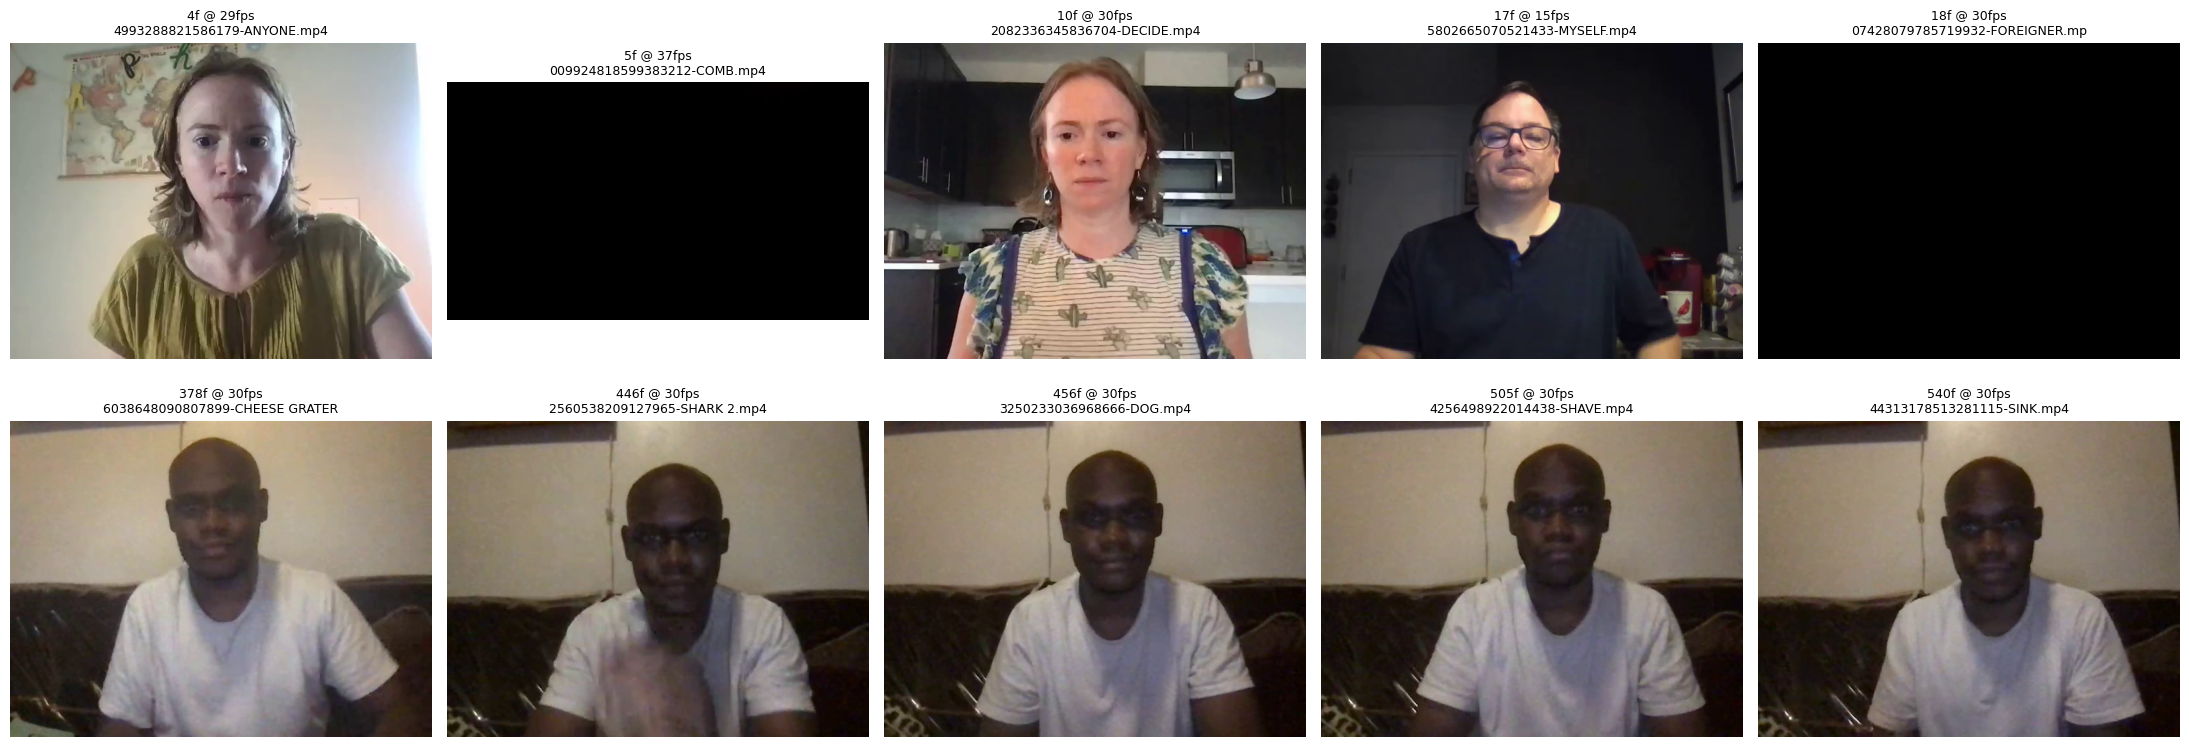

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Recompute frame counts with file references this time
video_info = []
for v in VIDEO_DIR.glob('*.mp4'):
    cap = cv2.VideoCapture(str(v))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frm = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    video_info.append({'path': v, 'name': v.name, 'fps': fps, 'frames': n_frm})

video_info_sorted = sorted(video_info, key=lambda d: d['frames'])

print("5 shortest videos:")
for d in video_info_sorted[:5]:
    print(f"  {d['name'][:60]:60s}  fps={d['fps']:.1f}  frames={d['frames']}")
print()
print("5 longest videos:")
for d in video_info_sorted[-5:]:
    print(f"  {d['name'][:60]:60s}  fps={d['fps']:.1f}  frames={d['frames']}")
print()

# Show first frame of shortest and a middle frame of longest
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for ax, d in zip(axes[0], video_info_sorted[:5]):
    cap = cv2.VideoCapture(str(d['path']))
    ok, frame = cap.read()
    cap.release()
    if ok:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{d['frames']}f @ {d['fps']:.0f}fps\n{d['name'][:30]}", fontsize=9)
    ax.axis('off')

for ax, d in zip(axes[1], video_info_sorted[-5:]):
    cap = cv2.VideoCapture(str(d['path']))
    cap.set(cv2.CAP_PROP_POS_FRAMES, d['frames'] // 2)
    ok, frame = cap.read()
    cap.release()
    if ok:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{d['frames']}f @ {d['fps']:.0f}fps\n{d['name'][:30]}", fontsize=9)
    ax.axis('off')

axes[0, 0].set_ylabel("Shortest", fontsize=12)
axes[1, 0].set_ylabel("Longest (middle frame)", fontsize=12)
plt.tight_layout()
plt.show()

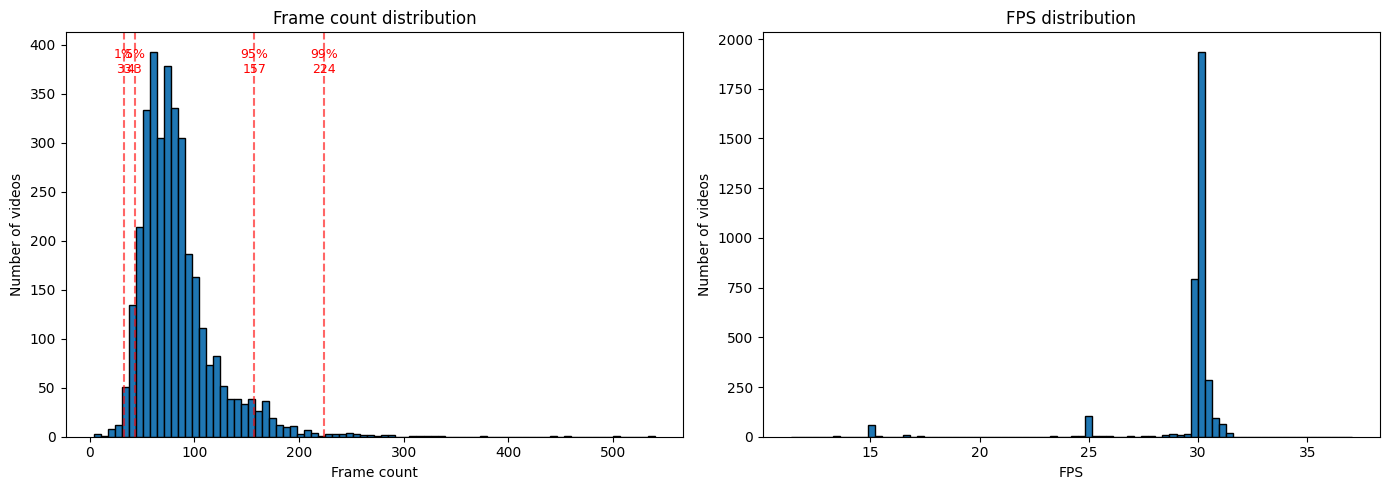

Frame count percentiles:
  p1: 33 frames
  p5: 43 frames
  p25: 59 frames
  p50: 76 frames
  p75: 95 frames
  p95: 157 frames
  p99: 224 frames


In [ ]:
import numpy as np

frame_counts_arr = np.array([d['frames'] for d in video_info])
fps_arr = np.array([d['fps'] for d in video_info])

# Frame count histogram with percentile lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(frame_counts_arr, bins=80, edgecolor='black')
for p in [1, 5, 95, 99]:
    val = np.percentile(frame_counts_arr, p)
    axes[0].axvline(val, color='red', linestyle='--', alpha=0.6)
    axes[0].text(val, axes[0].get_ylim()[1]*0.9, f'{p}%\n{val:.0f}',
                 ha='center', fontsize=9, color='red')
axes[0].set_xlabel('Frame count')
axes[0].set_ylabel('Number of videos')
axes[0].set_title('Frame count distribution')

axes[1].hist(fps_arr, bins=80, edgecolor='black')
axes[1].set_xlabel('FPS')
axes[1].set_ylabel('Number of videos')
axes[1].set_title('FPS distribution')

plt.tight_layout()
plt.show()

print(f"Frame count percentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{p}: {np.percentile(frame_counts_arr, p):.0f} frames")

In [ ]:
MIN_FRAMES = 25
MAX_FRAMES = 300

# Map filename -> frame count
frames_by_name = {d['name']: d['frames'] for d in video_info}

def filter_split(df, name):
    n_before = len(df)
    df = df.copy()
    df['n_frames'] = df['Video file'].map(frames_by_name)
    # Drop rows where the video isn't on disk (shouldn't happen, but defensive)
    n_missing = df['n_frames'].isna().sum()
    df = df.dropna(subset=['n_frames'])
    # Apply frame-count filter
    keep = (df['n_frames'] >= MIN_FRAMES) & (df['n_frames'] <= MAX_FRAMES)
    n_dropped_short = ((df['n_frames'] < MIN_FRAMES)).sum()
    n_dropped_long  = ((df['n_frames'] > MAX_FRAMES)).sum()
    df = df[keep].reset_index(drop=True)
    print(f"  {name}: {n_before} -> {len(df)}  "
          f"(dropped {n_dropped_short} short, {n_dropped_long} long, {n_missing} missing)")
    return df

print(f"Filtering to {MIN_FRAMES} <= frames <= {MAX_FRAMES}")
sub_train_f = filter_split(sub_train, 'train')
sub_val_f   = filter_split(sub_val,   'val')
sub_test_f  = filter_split(sub_test,  'test')

print()
print(f"Final subset:")
print(f"  Train: {len(sub_train_f)} videos  ({sub_train_f['Gloss'].nunique()} classes)")
print(f"  Val:   {len(sub_val_f)} videos  ({sub_val_f['Gloss'].nunique()} classes)")
print(f"  Test:  {len(sub_test_f)} videos  ({sub_test_f['Gloss'].nunique()} classes)")
print(f"  Total: {len(sub_train_f) + len(sub_val_f) + len(sub_test_f)} videos")

# Verify all 100 classes still present in all splits
classes_train = set(sub_train_f['Gloss'].unique())
classes_val   = set(sub_val_f['Gloss'].unique())
classes_test  = set(sub_test_f['Gloss'].unique())
all_three = classes_train & classes_val & classes_test
print(f"  Classes in all 3 splits: {len(all_three)} / 100")
if len(all_three) < 100:
    missing = set(top100_classes) - all_three
    print(f"  Lost classes: {missing}")

# Save filtered CSVs
sub_train_f.to_csv(SUBSET_DIR / 'train_filtered.csv', index=False)
sub_val_f.to_csv(SUBSET_DIR / 'val_filtered.csv', index=False)
sub_test_f.to_csv(SUBSET_DIR / 'test_filtered.csv', index=False)
print(f"\nSaved filtered CSVs to {SUBSET_DIR}")

Filtering to 25 <= frames <= 300
  train: 1800 -> 1790  (dropped 0 short, 10 long, 0 missing)
  val: 367 -> 367  (dropped 0 short, 0 long, 0 missing)
  test: 1286 -> 1274  (dropped 12 short, 0 long, 0 missing)

Final subset:
  Train: 1790 videos  (100 classes)
  Val:   367 videos  (100 classes)
  Test:  1274 videos  (100 classes)
  Total: 3431 videos
  Classes in all 3 splits: 100 / 100

Saved filtered CSVs to /content/drive/MyDrive/CAPSTONE_ASL/subset_top100


In [ ]:
import time
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Make sure mediapipe is installed and working
!pip install -q --upgrade mediapipe

# (You'll need to restart runtime after the install if mediapipe wasn't already loaded)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision

# Download model bundles if not already present
import os
if not os.path.exists('/tmp/hand_landmarker.task'):
    !wget -q -O /tmp/hand_landmarker.task \
      https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
if not os.path.exists('/tmp/pose_landmarker_full.task'):
    !wget -q -O /tmp/pose_landmarker_full.task \
      https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task
print("Models ready")

POSE_UPPER = [0, 11, 12, 13, 14, 15, 16]
N_POSE = len(POSE_UPPER)
N_HAND = 21

# Same aggressive thresholds — bare hands here so they may be more lenient
# than needed, but consistent settings help cross-dataset comparisons later
HAND_DETECTION_CONFIDENCE = 0.1
HAND_PRESENCE_CONFIDENCE  = 0.1
HAND_TRACKING_CONFIDENCE  = 0.1
POSE_DETECTION_CONFIDENCE = 0.5
POSE_TRACKING_CONFIDENCE  = 0.5


def make_landmarkers():
    hand_opts = vision.HandLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/hand_landmarker.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=HAND_DETECTION_CONFIDENCE,
        min_hand_presence_confidence=HAND_PRESENCE_CONFIDENCE,
        min_tracking_confidence=HAND_TRACKING_CONFIDENCE,
    )
    pose_opts = vision.PoseLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/pose_landmarker_full.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=POSE_DETECTION_CONFIDENCE,
        min_tracking_confidence=POSE_TRACKING_CONFIDENCE,
    )
    return (vision.HandLandmarker.create_from_options(hand_opts),
            vision.PoseLandmarker.create_from_options(pose_opts))


def extract_keypoints(video_path, hand_lmk, pose_lmk):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    pose_seq, lh_seq, rh_seq = [], [], []
    pose_mask, lh_mask, rh_mask = [], [], []
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

            hand_res = hand_lmk.detect(mp_img)
            pose_res = pose_lmk.detect(mp_img)

            pose = np.zeros((N_POSE, 3), dtype=np.float32)
            if pose_res.pose_landmarks:
                lms = pose_res.pose_landmarks[0]
                for o, i in enumerate(POSE_UPPER):
                    pose[o] = (lms[i].x, lms[i].y, lms[i].z)
                pose_mask.append(True)
            else:
                pose_mask.append(False)
            pose_seq.append(pose)

            lh = np.zeros((N_HAND, 3), dtype=np.float32)
            rh = np.zeros((N_HAND, 3), dtype=np.float32)
            lh_seen = rh_seen = False
            if hand_res.hand_landmarks:
                for hand_lms, handed in zip(hand_res.hand_landmarks, hand_res.handedness):
                    label = handed[0].category_name
                    target = lh if label == "Left" else rh
                    for i, lm in enumerate(hand_lms):
                        target[i] = (lm.x, lm.y, lm.z)
                    if label == "Left": lh_seen = True
                    else:               rh_seen = True
            lh_mask.append(lh_seen)
            rh_mask.append(rh_seen)
            lh_seq.append(lh)
            rh_seq.append(rh)
    finally:
        cap.release()
    return {
        "pose":      np.stack(pose_seq) if pose_seq else np.zeros((0, N_POSE, 3), dtype=np.float32),
        "lh":        np.stack(lh_seq)   if lh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "rh":        np.stack(rh_seq)   if rh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "pose_mask": np.array(pose_mask, dtype=bool),
        "lh_mask":   np.array(lh_mask,   dtype=bool),
        "rh_mask":   np.array(rh_mask,   dtype=bool),
        "fps":       np.float32(fps),
    }


# Time on 5 videos
all_filtered = pd.concat([sub_train_f, sub_val_f, sub_test_f], ignore_index=True)
test_paths = [VIDEO_DIR / f for f in all_filtered['Video file'].head(5)]

hand_lmk, pose_lmk = make_landmarkers()
times = []
for p in test_paths:
    t0 = time.time()
    kp = extract_keypoints(p, hand_lmk, pose_lmk)
    times.append(time.time() - t0)
    print(f"  {p.name[:50]:50s}  frames={kp['n_frames'] if 'n_frames' in kp else len(kp['pose'])}  "
          f"time={times[-1]:.2f}s  "
          f"R={kp['rh_mask'].mean():.0%} L={kp['lh_mask'].mean():.0%}")
hand_lmk.close()
pose_lmk.close()

avg_time = sum(times) / len(times)
total_videos = len(all_filtered)
est_total = avg_time * total_videos
print()
print(f"Avg per video: {avg_time:.2f}s")
print(f"Estimated total for {total_videos} videos: {est_total/60:.1f} min  ({est_total/3600:.1f} hours)")

Models ready
  15890366051589533-APPLE.mp4                         frames=71  time=7.91s  R=41% L=1%
  35618482303951104-IMPOSSIBLE.mp4                    frames=76  time=9.13s  R=28% L=45%
  8006032738002744-SOCCER 2.mp4                       frames=112  time=13.64s  R=29% L=37%
  4520498201410337-BACKPACK.mp4                       frames=76  time=8.44s  R=41% L=39%
  7448818785190525-CAPTURE.mp4                        frames=80  time=10.89s  R=35% L=44%

Avg per video: 10.00s
Estimated total for 3431 videos: 572.0 min  (9.5 hours)


In [ ]:
hand_lmk, pose_lmk = make_landmarkers()
for p in test_paths:
    kp = extract_keypoints(p, hand_lmk, pose_lmk)
    n = len(kp['pose'])
    rh = kp['rh_mask'].mean()
    lh = kp['lh_mask'].mean()
    either = (kp['rh_mask'] | kp['lh_mask']).mean()
    both = (kp['rh_mask'] & kp['lh_mask']).mean()
    print(f"  {p.name[:40]:40s}  R={rh:.0%} L={lh:.0%}  "
          f"either={either:.0%}  both={both:.0%}  pose={kp['pose_mask'].mean():.0%}")
hand_lmk.close()
pose_lmk.close()

  15890366051589533-APPLE.mp4               R=41% L=1%  either=42%  both=0%  pose=100%
  35618482303951104-IMPOSSIBLE.mp4          R=28% L=45%  either=46%  both=26%  pose=100%
  8006032738002744-SOCCER 2.mp4             R=29% L=37%  either=43%  both=22%  pose=100%
  4520498201410337-BACKPACK.mp4             R=41% L=39%  either=45%  both=36%  pose=100%
  7448818785190525-CAPTURE.mp4              R=35% L=44%  either=46%  both=32%  pose=100%


In [ ]:
import time

test_path = test_paths[0]

# Time MediaPipe alone (no I/O variance)
hand_lmk, pose_lmk = make_landmarkers()

cap = cv2.VideoCapture(str(test_path))
frames = []
while True:
    ok, f = cap.read()
    if not ok: break
    frames.append(f)
cap.release()

t0 = time.time()
for f in frames:
    rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    _ = hand_lmk.detect(img)
    _ = pose_lmk.detect(img)
t_mp = time.time() - t0

print(f"Frames:           {len(frames)}")
print(f"MediaPipe total:  {t_mp:.2f}s")
print(f"Per-frame:        {t_mp/len(frames)*1000:.0f}ms")
print(f"Resolution:       {frames[0].shape[1]}x{frames[0].shape[0]}")

hand_lmk.close()
pose_lmk.close()

Frames:           71
MediaPipe total:  9.07s
Per-frame:        128ms
Resolution:       640x480


In [ ]:
import numpy as np
import cv2

test_path = test_paths[0]  # APPLE
hand_lmk, pose_lmk = make_landmarkers()

cap = cv2.VideoCapture(str(test_path))
frames = []
while True:
    ok, f = cap.read()
    if not ok: break
    frames.append(f)
cap.release()

# For each frame: detect pose, then crop around each wrist and detect hands separately
full_frame_either = 0
cropped_either = 0
crop_size = 200  # pixels in 640x480 frame

for frame_bgr in frames:
    h, w = frame_bgr.shape[:2]
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    # 1. Full-frame detection (current method)
    full_hand = hand_lmk.detect(mp_img)
    full_seen = bool(full_hand.hand_landmarks)
    full_frame_either += int(full_seen)

    # 2. Pose-guided crops
    pose_res = pose_lmk.detect(mp_img)
    cropped_seen = False
    if pose_res.pose_landmarks:
        lms = pose_res.pose_landmarks[0]
        for wrist_idx in [15, 16]:  # left and right wrists
            cx = int(lms[wrist_idx].x * w)
            cy = int(lms[wrist_idx].y * h)
            # Tight crop around the wrist
            x0 = max(0, cx - crop_size // 2)
            y0 = max(0, cy - crop_size // 2)
            x1 = min(w, cx + crop_size // 2)
            y1 = min(h, cy + crop_size // 2)
            if x1 - x0 < 50 or y1 - y0 < 50:
                continue
            crop = rgb[y0:y1, x0:x1]
            crop_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(crop))
            crop_res = hand_lmk.detect(crop_img)
            if crop_res.hand_landmarks:
                cropped_seen = True
                break
    cropped_either += int(cropped_seen)

n = len(frames)
print(f"Test clip: {test_path.name}")
print(f"  Full-frame method:  either-hand detected on {full_frame_either}/{n} frames ({full_frame_either/n:.0%})")
print(f"  Wrist-crop method:  either-hand detected on {cropped_either}/{n} frames ({cropped_either/n:.0%})")

hand_lmk.close()
pose_lmk.close()

Test clip: 15890366051589533-APPLE.mp4
  Full-frame method:  either-hand detected on 30/71 frames (42%)
  Wrist-crop method:  either-hand detected on 27/71 frames (38%)


Success: 30/71
Detection pattern: .................RRRRRRRRRRRRRRRRRRRRRRRRRRRRRR........................


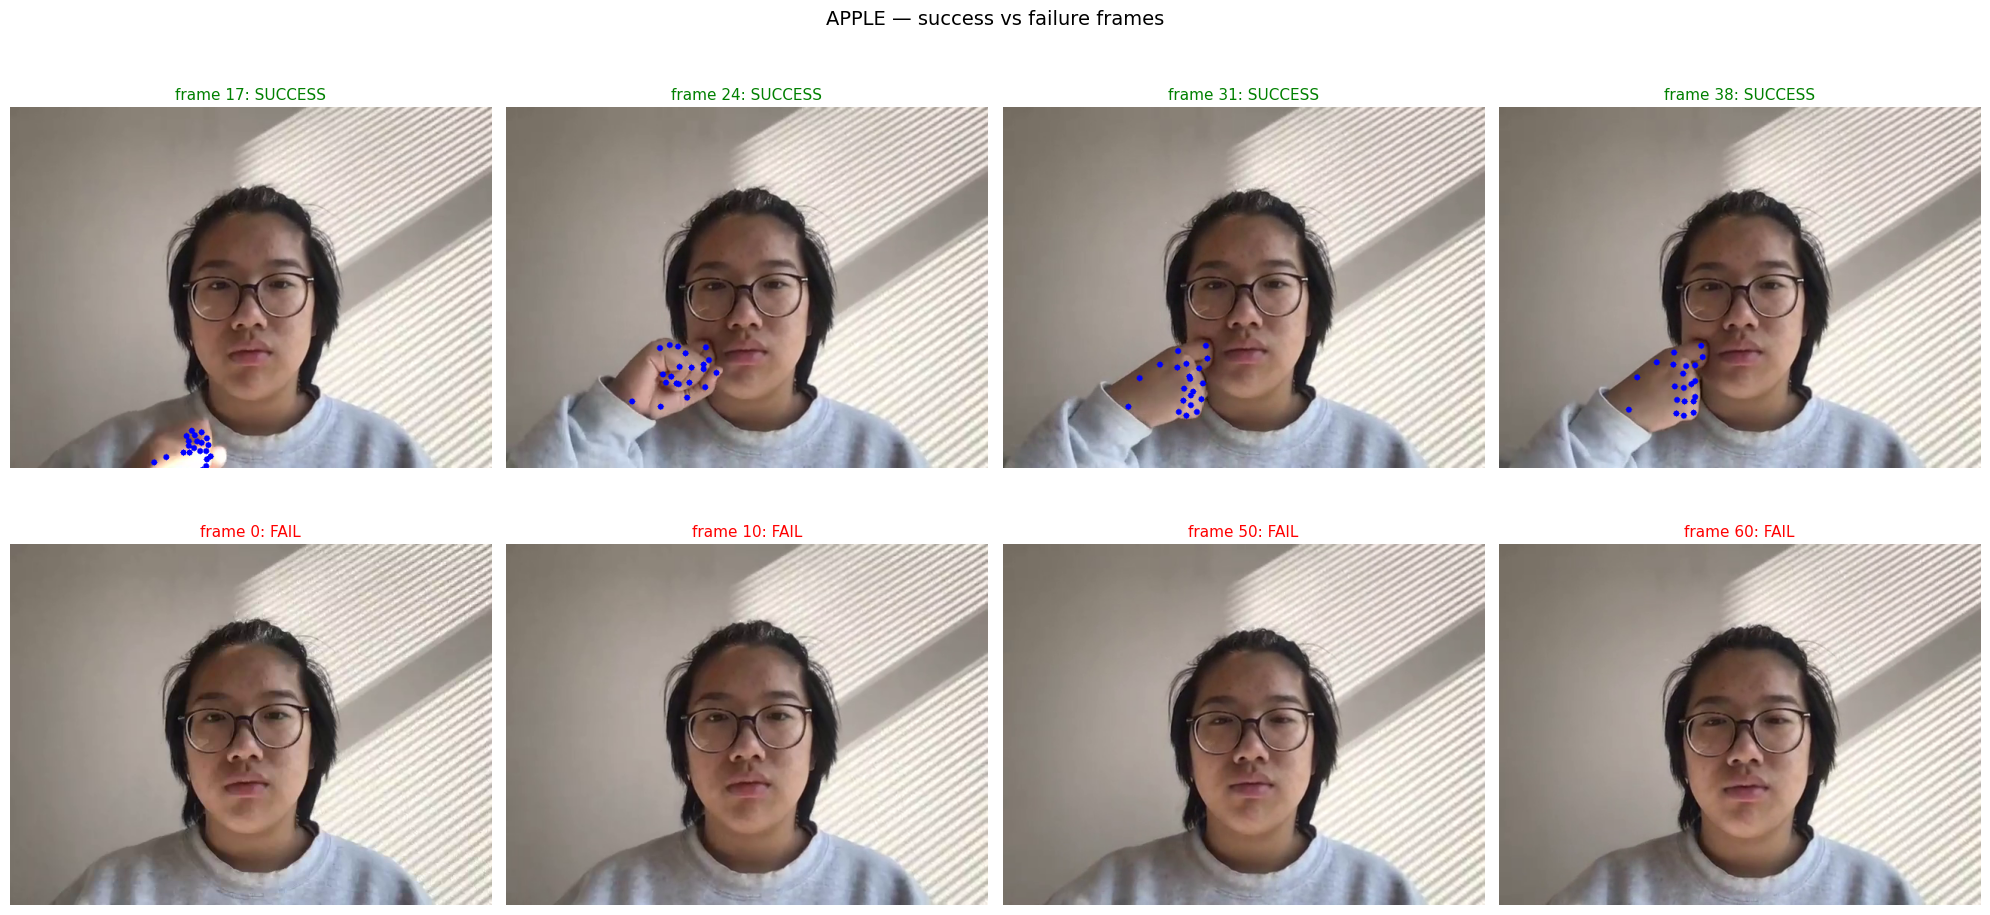

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

test_path = test_paths[0]  # APPLE
hand_lmk, pose_lmk = make_landmarkers()

cap = cv2.VideoCapture(str(test_path))
all_frames = []
while True:
    ok, f = cap.read()
    if not ok: break
    all_frames.append(f)
cap.release()

# Run detection on each frame, record which succeeded
success_idx = []
fail_idx = []
for i, frame_bgr in enumerate(all_frames):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    res = hand_lmk.detect(mp_img)
    if res.hand_landmarks:
        success_idx.append(i)
    else:
        fail_idx.append(i)

print(f"Success: {len(success_idx)}/{len(all_frames)}")
print(f"Detection pattern: ", end='')
print(''.join('R' if i in success_idx else '.' for i in range(len(all_frames))))

# Show 4 success frames and 4 failure frames
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

success_samples = success_idx[::max(1, len(success_idx)//4)][:4]
fail_samples    = fail_idx[::max(1, len(fail_idx)//4)][:4]

for ax, idx in zip(axes[0], success_samples):
    frame = all_frames[idx]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Re-run detection to get landmarks for drawing
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    res = hand_lmk.detect(mp_img)
    annotated = rgb.copy()
    h, w = annotated.shape[:2]
    if res.hand_landmarks:
        for hand_lms in res.hand_landmarks:
            for lm in hand_lms:
                cv2.circle(annotated, (int(lm.x*w), int(lm.y*h)), 4, (0, 0, 255), -1)
    ax.imshow(annotated)
    ax.set_title(f"frame {idx}: SUCCESS", fontsize=11, color='green')
    ax.axis('off')

for ax, idx in zip(axes[1], fail_samples):
    ax.imshow(cv2.cvtColor(all_frames[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}: FAIL", fontsize=11, color='red')
    ax.axis('off')

plt.suptitle(f"APPLE — success vs failure frames", fontsize=14)
plt.tight_layout()
plt.show()

hand_lmk.close()
pose_lmk.close()

In [ ]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import zipfile
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/CAPSTONE_ASL')
DOWNLOAD_DIR = PROJECT_ROOT / 'download'
SUBSET_DIR   = PROJECT_ROOT / 'subset_top100'
KEYPOINT_DIR = PROJECT_ROOT / 'keypoints'
SUBSET_DIR.mkdir(exist_ok=True)
KEYPOINT_DIR.mkdir(exist_ok=True)

zip_path = DOWNLOAD_DIR / 'ASL_Citizen.zip'

# Extract just the CSVs to Colab's local disk (don't bother with Drive for these)
LOCAL_BASE = Path('/content/asl_local')
LOCAL_BASE.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    for csv in ['ASL_Citizen/splits/train.csv',
                'ASL_Citizen/splits/val.csv',
                'ASL_Citizen/splits/test.csv']:
        z.extract(csv, path=LOCAL_BASE)

train_df = pd.read_csv(LOCAL_BASE / 'ASL_Citizen/splits/train.csv')
val_df   = pd.read_csv(LOCAL_BASE / 'ASL_Citizen/splits/val.csv')
test_df  = pd.read_csv(LOCAL_BASE / 'ASL_Citizen/splits/test.csv')

# Pick top-100 most frequent classes by training count
class_counts = train_df['Gloss'].value_counts()
top100 = set(class_counts.head(100).index)

sub_train = train_df[train_df['Gloss'].isin(top100)].reset_index(drop=True)
sub_val   = val_df[val_df['Gloss'].isin(top100)].reset_index(drop=True)
sub_test  = test_df[test_df['Gloss'].isin(top100)].reset_index(drop=True)

print(f"Subset: train={len(sub_train)} val={len(sub_val)} test={len(sub_test)}")

Subset: train=1800 val=367 test=1286


In [ ]:
sub_train.to_csv(SUBSET_DIR / 'train.csv', index=False)
sub_val.to_csv(SUBSET_DIR / 'val.csv', index=False)
sub_test.to_csv(SUBSET_DIR / 'test.csv', index=False)

# Flush Drive so these small files actually sync
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

# Verify
for n in ['train.csv', 'val.csv', 'test.csv']:
    p = SUBSET_DIR / n
    print(f"  {n}: {'OK' if p.exists() else 'MISSING'}  ({p.stat().st_size if p.exists() else 0} bytes)")

Mounted at /content/drive
  train.csv: OK  (89705 bytes)
  val.csv: OK  (18271 bytes)
  test.csv: OK  (63693 bytes)


In [ ]:
from tqdm.auto import tqdm

LOCAL_VIDEO_DIR = LOCAL_BASE / 'videos'
LOCAL_VIDEO_DIR.mkdir(exist_ok=True)

all_subset = pd.concat([sub_train, sub_val, sub_test], ignore_index=True)
needed_files = set(all_subset['Video file'].tolist())
needed_zip_paths = {f'ASL_Citizen/videos/{f}' for f in needed_files}

print(f"Extracting {len(needed_zip_paths)} videos to local disk...")
extracted = skipped = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    for member in tqdm(needed_zip_paths):
        out_path = LOCAL_BASE / member  # /content/asl_local/ASL_Citizen/videos/...
        if out_path.exists():
            skipped += 1
            continue
        z.extract(member, path=LOCAL_BASE)
        extracted += 1

print(f"\nExtracted: {extracted}  Already there: {skipped}")

# Quick sanity check
all_videos = list((LOCAL_BASE / 'ASL_Citizen/videos').glob('*.mp4'))
print(f"Videos on local disk: {len(all_videos)}")

Extracting 3453 videos to local disk...


  0%|          | 0/3453 [00:00<?, ?it/s]


Extracted: 3453  Already there: 0
Videos on local disk: 3453


In [ ]:
import numpy as np
import cv2
import time
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision
from google.colab import drive

# Local video directory (fast disk, not Drive)
LOCAL_VIDEO_DIR = LOCAL_BASE / 'ASL_Citizen' / 'videos'
assert LOCAL_VIDEO_DIR.exists(), f"Missing: {LOCAL_VIDEO_DIR}"
print(f"Source videos: {LOCAL_VIDEO_DIR}  ({len(list(LOCAL_VIDEO_DIR.glob('*.mp4')))} files)")

# Download MediaPipe models if needed
if not os.path.exists('/tmp/hand_landmarker.task'):
    !wget -q -O /tmp/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
if not os.path.exists('/tmp/pose_landmarker_full.task'):
    !wget -q -O /tmp/pose_landmarker_full.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

POSE_UPPER = [0, 11, 12, 13, 14, 15, 16]
N_POSE = len(POSE_UPPER)
N_HAND = 21


def make_landmarkers():
    hand_opts = vision.HandLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/hand_landmarker.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.1,
        min_hand_presence_confidence=0.1,
        min_tracking_confidence=0.1,
    )
    pose_opts = vision.PoseLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/pose_landmarker_full.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return (vision.HandLandmarker.create_from_options(hand_opts),
            vision.PoseLandmarker.create_from_options(pose_opts))


def extract_keypoints(video_path, hand_lmk, pose_lmk):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    pose_seq, lh_seq, rh_seq = [], [], []
    pose_mask, lh_mask, rh_mask = [], [], []
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            hand_res = hand_lmk.detect(mp_img)
            pose_res = pose_lmk.detect(mp_img)

            pose = np.zeros((N_POSE, 3), dtype=np.float32)
            if pose_res.pose_landmarks:
                lms = pose_res.pose_landmarks[0]
                for o, i in enumerate(POSE_UPPER):
                    pose[o] = (lms[i].x, lms[i].y, lms[i].z)
                pose_mask.append(True)
            else:
                pose_mask.append(False)
            pose_seq.append(pose)

            lh = np.zeros((N_HAND, 3), dtype=np.float32)
            rh = np.zeros((N_HAND, 3), dtype=np.float32)
            lh_seen = rh_seen = False
            if hand_res.hand_landmarks:
                for hand_lms, handed in zip(hand_res.hand_landmarks, hand_res.handedness):
                    label = handed[0].category_name
                    target = lh if label == "Left" else rh
                    for i, lm in enumerate(hand_lms):
                        target[i] = (lm.x, lm.y, lm.z)
                    if label == "Left": lh_seen = True
                    else:               rh_seen = True
            lh_mask.append(lh_seen)
            rh_mask.append(rh_seen)
            lh_seq.append(lh)
            rh_seq.append(rh)
    finally:
        cap.release()
    return {
        "pose":      np.stack(pose_seq) if pose_seq else np.zeros((0, N_POSE, 3), dtype=np.float32),
        "lh":        np.stack(lh_seq)   if lh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "rh":        np.stack(rh_seq)   if rh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "pose_mask": np.array(pose_mask, dtype=bool),
        "lh_mask":   np.array(lh_mask,   dtype=bool),
        "rh_mask":   np.array(rh_mask,   dtype=bool),
        "fps":       np.float32(fps),
    }


def output_path_for(video_filename):
    return KEYPOINT_DIR / f"{Path(video_filename).stem}.npz"


def process_subset(df, name, log_every=25, flush_every=200, time_budget_sec=None):
    """Process a subset. Periodically flushes Drive so writes are durable.
    time_budget_sec lets us stop gracefully before Colab disconnects."""
    n_total = len(df)
    n_done = n_skipped = n_failed = 0
    n_since_flush = 0
    t_start = time.time()

    hand_lmk, pose_lmk = make_landmarkers()
    try:
        for i, row in enumerate(df.itertuples(), 1):
            if time_budget_sec is not None and (time.time() - t_start) > time_budget_sec:
                print(f"  [{name}] time budget reached at {i}/{n_total}")
                break

            video_file = row._2  # 'Video file' column
            video_path = LOCAL_VIDEO_DIR / video_file
            out_path = output_path_for(video_file)

            if out_path.exists():
                n_skipped += 1
                continue
            if not video_path.exists():
                print(f"  MISSING: {video_file}")
                n_failed += 1
                continue

            try:
                kp = extract_keypoints(video_path, hand_lmk, pose_lmk)
                np.savez_compressed(out_path, **kp)
                n_done += 1
                n_since_flush += 1
            except Exception as e:
                print(f"  FAIL {video_file}: {e}")
                n_failed += 1

            if n_since_flush >= flush_every:
                # Force flush so saved files actually persist to Drive
                drive.flush_and_unmount()
                drive.mount('/content/drive')
                n_since_flush = 0
                print(f"  [{name} {i}/{n_total}] flushed Drive ✓")

            if i % log_every == 0 or i == n_total:
                elapsed = time.time() - t_start
                rate = i / elapsed if elapsed else 0
                eta = (n_total - i) / rate if rate else 0
                print(f"  [{name} {i}/{n_total}] done={n_done} skip={n_skipped} fail={n_failed}  "
                      f"rate={rate:.2f}/s  eta={eta/60:.1f}min")
    finally:
        hand_lmk.close()
        pose_lmk.close()
        # Final flush
        drive.flush_and_unmount()
        drive.mount('/content/drive')

    elapsed = time.time() - t_start
    return {"done": n_done, "skipped": n_skipped, "failed": n_failed,
            "elapsed_min": elapsed/60}


def status():
    existing = list(KEYPOINT_DIR.glob('*.npz'))
    total = len(sub_train) + len(sub_val) + len(sub_test)
    print(f"Keypoints saved: {len(existing)} / {total} ({len(existing)/total:.1%})")
    train_done = sum(output_path_for(f).exists() for f in sub_train['Video file'])
    val_done   = sum(output_path_for(f).exists() for f in sub_val['Video file'])
    test_done  = sum(output_path_for(f).exists() for f in sub_test['Video file'])
    print(f"  train: {train_done}/{len(sub_train)}")
    print(f"  val:   {val_done}/{len(sub_val)}")
    print(f"  test:  {test_done}/{len(sub_test)}")

status()

Source videos: /content/asl_local/ASL_Citizen/videos  (3453 files)
Keypoints saved: 0 / 3453 (0.0%)
  train: 0/1800
  val:   0/367
  test:  0/1286


In [ ]:
# 2 hours of train after val finishes — leaves headroom for the session
stats = process_subset(sub_train, 'train', time_budget_sec=2 * 60 * 60)
print(f"\nTrain partial: {stats}")
status()

  [train 25/1800] done=25 skip=0 fail=0  rate=0.13/s  eta=233.6min
  [train 50/1800] done=50 skip=0 fail=0  rate=0.12/s  eta=240.5min
  [train 75/1800] done=75 skip=0 fail=0  rate=0.12/s  eta=230.8min
  [train 100/1800] done=100 skip=0 fail=0  rate=0.13/s  eta=214.5min
  [train 125/1800] done=125 skip=0 fail=0  rate=0.13/s  eta=207.8min
  [train 150/1800] done=150 skip=0 fail=0  rate=0.14/s  eta=200.3min
  [train 175/1800] done=175 skip=0 fail=0  rate=0.14/s  eta=194.4min
Mounted at /content/drive
  [train 200/1800] flushed Drive ✓
  [train 200/1800] done=200 skip=0 fail=0  rate=0.14/s  eta=191.5min
  [train 225/1800] done=225 skip=0 fail=0  rate=0.14/s  eta=184.4min
  [train 250/1800] done=250 skip=0 fail=0  rate=0.14/s  eta=179.7min
  [train 275/1800] done=275 skip=0 fail=0  rate=0.14/s  eta=175.6min
  [train 300/1800] done=300 skip=0 fail=0  rate=0.15/s  eta=168.7min
  [train 325/1800] done=325 skip=0 fail=0  rate=0.15/s  eta=161.8min
  [train 350/1800] done=350 skip=0 fail=0  rate=

In [ ]:
stats = process_subset(sub_val, 'val')
print(f"\nVal done: {stats}")
status()

  [val 25/367] done=25 skip=0 fail=0  rate=0.18/s  eta=32.1min
  [val 50/367] done=50 skip=0 fail=0  rate=0.18/s  eta=30.2min
  [val 75/367] done=75 skip=0 fail=0  rate=0.16/s  eta=29.9min
  [val 100/367] done=100 skip=0 fail=0  rate=0.14/s  eta=32.1min
  [val 125/367] done=125 skip=0 fail=0  rate=0.15/s  eta=26.5min
  [val 150/367] done=150 skip=0 fail=0  rate=0.16/s  eta=23.2min
  [val 175/367] done=175 skip=0 fail=0  rate=0.16/s  eta=19.8min
Mounted at /content/drive
  [val 200/367] flushed Drive ✓
  [val 200/367] done=200 skip=0 fail=0  rate=0.14/s  eta=19.6min
  [val 225/367] done=225 skip=0 fail=0  rate=0.14/s  eta=17.4min
  [val 250/367] done=250 skip=0 fail=0  rate=0.13/s  eta=14.7min
  [val 275/367] done=275 skip=0 fail=0  rate=0.13/s  eta=11.6min
  [val 300/367] done=300 skip=0 fail=0  rate=0.13/s  eta=8.3min
  [val 325/367] done=325 skip=0 fail=0  rate=0.14/s  eta=5.2min
  [val 350/367] done=350 skip=0 fail=0  rate=0.14/s  eta=2.1min
  [val 367/367] done=367 skip=0 fail=0  r

In [ ]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import time
import cv2
import zipfile
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/content/drive/MyDrive/CAPSTONE_ASL')
DOWNLOAD_DIR = PROJECT_ROOT / 'download'
SUBSET_DIR   = PROJECT_ROOT / 'subset_top100'
KEYPOINT_DIR = PROJECT_ROOT / 'keypoints'
LOCAL_BASE   = Path('/content/asl_local')
LOCAL_BASE.mkdir(exist_ok=True)
LOCAL_VIDEO_DIR = LOCAL_BASE / 'ASL_Citizen' / 'videos'

zip_path = DOWNLOAD_DIR / 'ASL_Citizen.zip'
assert zip_path.exists(), f"Zip missing: {zip_path}"
print(f"Zip on Drive: {zip_path.stat().st_size / 1e9:.1f} GB")

sub_train = pd.read_csv(SUBSET_DIR / 'train.csv')
sub_val   = pd.read_csv(SUBSET_DIR / 'val.csv')
sub_test  = pd.read_csv(SUBSET_DIR / 'test.csv')

existing = list(KEYPOINT_DIR.glob('*.npz'))
total = len(sub_train) + len(sub_val) + len(sub_test)
print(f"Keypoints already done: {len(existing)} / {total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip on Drive: 45.9 GB
Keypoints already done: 1428 / 3453


In [ ]:
all_subset = pd.concat([sub_train, sub_val, sub_test])

needed_filenames = []
for f in all_subset['Video file']:
    out_kp = KEYPOINT_DIR / f"{Path(f).stem}.npz"
    if not out_kp.exists():
        needed_filenames.append(f)

print(f"Videos still needing keypoints: {len(needed_filenames)}")

with zipfile.ZipFile(zip_path, 'r') as z:
    for csv in ['ASL_Citizen/splits/train.csv',
                'ASL_Citizen/splits/val.csv',
                'ASL_Citizen/splits/test.csv']:
        z.extract(csv, path=LOCAL_BASE)

    print(f"Unzipping {len(needed_filenames)} videos to local disk...")
    for f in tqdm(needed_filenames):
        member = f'ASL_Citizen/videos/{f}'
        out_path = LOCAL_BASE / member
        if not out_path.exists():
            z.extract(member, path=LOCAL_BASE)

print(f"Videos on local disk: {len(list(LOCAL_VIDEO_DIR.glob('*.mp4')))}")

Videos still needing keypoints: 2025
Unzipping 2025 videos to local disk...


  0%|          | 0/2025 [00:00<?, ?it/s]

Videos on local disk: 3453


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision

if not os.path.exists('/tmp/hand_landmarker.task'):
    !wget -q -O /tmp/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
if not os.path.exists('/tmp/pose_landmarker_full.task'):
    !wget -q -O /tmp/pose_landmarker_full.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

POSE_UPPER = [0, 11, 12, 13, 14, 15, 16]
N_POSE = len(POSE_UPPER)
N_HAND = 21


def make_landmarkers():
    hand_opts = vision.HandLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/hand_landmarker.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.1,
        min_hand_presence_confidence=0.1,
        min_tracking_confidence=0.1,
    )
    pose_opts = vision.PoseLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/pose_landmarker_full.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return (vision.HandLandmarker.create_from_options(hand_opts),
            vision.PoseLandmarker.create_from_options(pose_opts))


def extract_keypoints(video_path, hand_lmk, pose_lmk):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    pose_seq, lh_seq, rh_seq = [], [], []
    pose_mask, lh_mask, rh_mask = [], [], []
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            hand_res = hand_lmk.detect(mp_img)
            pose_res = pose_lmk.detect(mp_img)

            pose = np.zeros((N_POSE, 3), dtype=np.float32)
            if pose_res.pose_landmarks:
                lms = pose_res.pose_landmarks[0]
                for o, i in enumerate(POSE_UPPER):
                    pose[o] = (lms[i].x, lms[i].y, lms[i].z)
                pose_mask.append(True)
            else:
                pose_mask.append(False)
            pose_seq.append(pose)

            lh = np.zeros((N_HAND, 3), dtype=np.float32)
            rh = np.zeros((N_HAND, 3), dtype=np.float32)
            lh_seen = rh_seen = False
            if hand_res.hand_landmarks:
                for hand_lms, handed in zip(hand_res.hand_landmarks, hand_res.handedness):
                    label = handed[0].category_name
                    target = lh if label == "Left" else rh
                    for i, lm in enumerate(hand_lms):
                        target[i] = (lm.x, lm.y, lm.z)
                    if label == "Left": lh_seen = True
                    else:               rh_seen = True
            lh_mask.append(lh_seen)
            rh_mask.append(rh_seen)
            lh_seq.append(lh)
            rh_seq.append(rh)
    finally:
        cap.release()
    return {
        "pose":      np.stack(pose_seq) if pose_seq else np.zeros((0, N_POSE, 3), dtype=np.float32),
        "lh":        np.stack(lh_seq)   if lh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "rh":        np.stack(rh_seq)   if rh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "pose_mask": np.array(pose_mask, dtype=bool),
        "lh_mask":   np.array(lh_mask,   dtype=bool),
        "rh_mask":   np.array(rh_mask,   dtype=bool),
        "fps":       np.float32(fps),
    }


def output_path_for(video_filename):
    return KEYPOINT_DIR / f"{Path(video_filename).stem}.npz"


def process_subset(df, name, log_every=25, flush_every=200, time_budget_sec=None):
    n_total = len(df)
    n_done = n_skipped = n_failed = 0
    n_since_flush = 0
    t_start = time.time()

    hand_lmk, pose_lmk = make_landmarkers()
    try:
        for i, row in enumerate(df.itertuples(), 1):
            if time_budget_sec is not None and (time.time() - t_start) > time_budget_sec:
                print(f"  [{name}] time budget reached at {i}/{n_total}")
                break

            video_file = row._2
            video_path = LOCAL_VIDEO_DIR / video_file
            out_path = output_path_for(video_file)

            if out_path.exists():
                n_skipped += 1
                continue
            if not video_path.exists():
                print(f"  MISSING: {video_file}")
                n_failed += 1
                continue

            try:
                kp = extract_keypoints(video_path, hand_lmk, pose_lmk)
                np.savez_compressed(out_path, **kp)
                n_done += 1
                n_since_flush += 1
            except Exception as e:
                print(f"  FAIL {video_file}: {e}")
                n_failed += 1

            if n_since_flush >= flush_every:
                drive.flush_and_unmount()
                drive.mount('/content/drive')
                n_since_flush = 0
                print(f"  [{name} {i}/{n_total}] flushed Drive ✓")

            if i % log_every == 0 or i == n_total:
                elapsed = time.time() - t_start
                rate = i / elapsed if elapsed else 0
                eta = (n_total - i) / rate if rate else 0
                print(f"  [{name} {i}/{n_total}] done={n_done} skip={n_skipped} fail={n_failed}  "
                      f"rate={rate:.2f}/s  eta={eta/60:.1f}min")
    finally:
        hand_lmk.close()
        pose_lmk.close()
        drive.flush_and_unmount()
        drive.mount('/content/drive')

    elapsed = time.time() - t_start
    return {"done": n_done, "skipped": n_skipped, "failed": n_failed,
            "elapsed_min": elapsed/60}


def status():
    existing = list(KEYPOINT_DIR.glob('*.npz'))
    total = len(sub_train) + len(sub_val) + len(sub_test)
    print(f"Keypoints saved: {len(existing)} / {total} ({len(existing)/total:.1%})")
    train_done = sum(output_path_for(f).exists() for f in sub_train['Video file'])
    val_done   = sum(output_path_for(f).exists() for f in sub_val['Video file'])
    test_done  = sum(output_path_for(f).exists() for f in sub_test['Video file'])
    print(f"  train: {train_done}/{len(sub_train)}")
    print(f"  val:   {val_done}/{len(sub_val)}")
    print(f"  test:  {test_done}/{len(sub_test)}")

status()

Keypoints saved: 1428 / 3453 (41.4%)
  train: 1061/1800
  val:   367/367
  test:  0/1286


In [ ]:
stats = process_subset(sub_train, 'train')
print(f"\nTrain complete: {stats}")
status()

  [train 1075/1800] done=14 skip=1061 fail=0  rate=12.95/s  eta=0.9min
  [train 1100/1800] done=39 skip=1061 fail=0  rate=5.22/s  eta=2.2min
  [train 1125/1800] done=64 skip=1061 fail=0  rate=2.73/s  eta=4.1min
  [train 1150/1800] done=89 skip=1061 fail=0  rate=1.89/s  eta=5.7min
  [train 1175/1800] done=114 skip=1061 fail=0  rate=1.51/s  eta=6.9min
  [train 1200/1800] done=139 skip=1061 fail=0  rate=1.29/s  eta=7.8min
  [train 1225/1800] done=164 skip=1061 fail=0  rate=1.13/s  eta=8.5min
  [train 1250/1800] done=189 skip=1061 fail=0  rate=1.00/s  eta=9.2min
Mounted at /content/drive
  [train 1261/1800] flushed Drive ✓
  [train 1275/1800] done=214 skip=1061 fail=0  rate=0.91/s  eta=9.7min
  [train 1300/1800] done=239 skip=1061 fail=0  rate=0.74/s  eta=11.3min
  [train 1325/1800] done=264 skip=1061 fail=0  rate=0.65/s  eta=12.2min
  [train 1350/1800] done=289 skip=1061 fail=0  rate=0.57/s  eta=13.1min
  [train 1375/1800] done=314 skip=1061 fail=0  rate=0.51/s  eta=13.8min
  [train 1400/

In [ ]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import time
import cv2
import zipfile
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/content/drive/MyDrive/CAPSTONE_ASL')
DOWNLOAD_DIR = PROJECT_ROOT / 'download'
SUBSET_DIR   = PROJECT_ROOT / 'subset_top100'
KEYPOINT_DIR = PROJECT_ROOT / 'keypoints'
LOCAL_BASE   = Path('/content/asl_local')
LOCAL_BASE.mkdir(exist_ok=True)
LOCAL_VIDEO_DIR = LOCAL_BASE / 'ASL_Citizen' / 'videos'

zip_path = DOWNLOAD_DIR / 'ASL_Citizen.zip'
assert zip_path.exists(), f"Zip missing: {zip_path}"
print(f"Zip on Drive: {zip_path.stat().st_size / 1e9:.1f} GB")

sub_train = pd.read_csv(SUBSET_DIR / 'train.csv')
sub_val   = pd.read_csv(SUBSET_DIR / 'val.csv')
sub_test  = pd.read_csv(SUBSET_DIR / 'test.csv')

existing = list(KEYPOINT_DIR.glob('*.npz'))
total = len(sub_train) + len(sub_val) + len(sub_test)
print(f"Keypoints already done: {len(existing)} / {total}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip on Drive: 45.9 GB
Keypoints already done: 2167 / 3453


In [ ]:
all_subset = pd.concat([sub_train, sub_val, sub_test])

needed_filenames = []
for f in all_subset['Video file']:
    out_kp = KEYPOINT_DIR / f"{Path(f).stem}.npz"
    if not out_kp.exists():
        needed_filenames.append(f)

print(f"Videos still needing keypoints: {len(needed_filenames)}")

with zipfile.ZipFile(zip_path, 'r') as z:
    for csv in ['ASL_Citizen/splits/train.csv',
                'ASL_Citizen/splits/val.csv',
                'ASL_Citizen/splits/test.csv']:
        z.extract(csv, path=LOCAL_BASE)

    print(f"Unzipping {len(needed_filenames)} videos to local disk...")
    for f in tqdm(needed_filenames):
        member = f'ASL_Citizen/videos/{f}'
        out_path = LOCAL_BASE / member
        if not out_path.exists():
            z.extract(member, path=LOCAL_BASE)

print(f"Videos on local disk: {len(list(LOCAL_VIDEO_DIR.glob('*.mp4')))}")

Videos still needing keypoints: 1286
Unzipping 1286 videos to local disk...


  0%|          | 0/1286 [00:00<?, ?it/s]

Videos on local disk: 3453


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision

if not os.path.exists('/tmp/hand_landmarker.task'):
    !wget -q -O /tmp/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
if not os.path.exists('/tmp/pose_landmarker_full.task'):
    !wget -q -O /tmp/pose_landmarker_full.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

POSE_UPPER = [0, 11, 12, 13, 14, 15, 16]
N_POSE = len(POSE_UPPER)
N_HAND = 21


def make_landmarkers():
    hand_opts = vision.HandLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/hand_landmarker.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.1,
        min_hand_presence_confidence=0.1,
        min_tracking_confidence=0.1,
    )
    pose_opts = vision.PoseLandmarkerOptions(
        base_options=mp_tasks.BaseOptions(model_asset_path='/tmp/pose_landmarker_full.task'),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return (vision.HandLandmarker.create_from_options(hand_opts),
            vision.PoseLandmarker.create_from_options(pose_opts))


def extract_keypoints(video_path, hand_lmk, pose_lmk):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    pose_seq, lh_seq, rh_seq = [], [], []
    pose_mask, lh_mask, rh_mask = [], [], []
    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            hand_res = hand_lmk.detect(mp_img)
            pose_res = pose_lmk.detect(mp_img)

            pose = np.zeros((N_POSE, 3), dtype=np.float32)
            if pose_res.pose_landmarks:
                lms = pose_res.pose_landmarks[0]
                for o, i in enumerate(POSE_UPPER):
                    pose[o] = (lms[i].x, lms[i].y, lms[i].z)
                pose_mask.append(True)
            else:
                pose_mask.append(False)
            pose_seq.append(pose)

            lh = np.zeros((N_HAND, 3), dtype=np.float32)
            rh = np.zeros((N_HAND, 3), dtype=np.float32)
            lh_seen = rh_seen = False
            if hand_res.hand_landmarks:
                for hand_lms, handed in zip(hand_res.hand_landmarks, hand_res.handedness):
                    label = handed[0].category_name
                    target = lh if label == "Left" else rh
                    for i, lm in enumerate(hand_lms):
                        target[i] = (lm.x, lm.y, lm.z)
                    if label == "Left": lh_seen = True
                    else:               rh_seen = True
            lh_mask.append(lh_seen)
            rh_mask.append(rh_seen)
            lh_seq.append(lh)
            rh_seq.append(rh)
    finally:
        cap.release()
    return {
        "pose":      np.stack(pose_seq) if pose_seq else np.zeros((0, N_POSE, 3), dtype=np.float32),
        "lh":        np.stack(lh_seq)   if lh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "rh":        np.stack(rh_seq)   if rh_seq   else np.zeros((0, N_HAND, 3), dtype=np.float32),
        "pose_mask": np.array(pose_mask, dtype=bool),
        "lh_mask":   np.array(lh_mask,   dtype=bool),
        "rh_mask":   np.array(rh_mask,   dtype=bool),
        "fps":       np.float32(fps),
    }


def output_path_for(video_filename):
    return KEYPOINT_DIR / f"{Path(video_filename).stem}.npz"


def process_subset(df, name, log_every=25, flush_every=200, time_budget_sec=None):
    n_total = len(df)
    n_done = n_skipped = n_failed = 0
    n_since_flush = 0
    t_start = time.time()

    hand_lmk, pose_lmk = make_landmarkers()
    try:
        for i, row in enumerate(df.itertuples(), 1):
            if time_budget_sec is not None and (time.time() - t_start) > time_budget_sec:
                print(f"  [{name}] time budget reached at {i}/{n_total}")
                break

            video_file = row._2
            video_path = LOCAL_VIDEO_DIR / video_file
            out_path = output_path_for(video_file)

            if out_path.exists():
                n_skipped += 1
                continue
            if not video_path.exists():
                print(f"  MISSING: {video_file}")
                n_failed += 1
                continue

            try:
                kp = extract_keypoints(video_path, hand_lmk, pose_lmk)
                np.savez_compressed(out_path, **kp)
                n_done += 1
                n_since_flush += 1
            except Exception as e:
                print(f"  FAIL {video_file}: {e}")
                n_failed += 1

            if n_since_flush >= flush_every:
                drive.flush_and_unmount()
                drive.mount('/content/drive')
                n_since_flush = 0
                print(f"  [{name} {i}/{n_total}] flushed Drive ✓")

            if i % log_every == 0 or i == n_total:
                elapsed = time.time() - t_start
                rate = i / elapsed if elapsed else 0
                eta = (n_total - i) / rate if rate else 0
                print(f"  [{name} {i}/{n_total}] done={n_done} skip={n_skipped} fail={n_failed}  "
                      f"rate={rate:.2f}/s  eta={eta/60:.1f}min")
    finally:
        hand_lmk.close()
        pose_lmk.close()
        drive.flush_and_unmount()
        drive.mount('/content/drive')

    elapsed = time.time() - t_start
    return {"done": n_done, "skipped": n_skipped, "failed": n_failed,
            "elapsed_min": elapsed/60}


def status():
    existing = list(KEYPOINT_DIR.glob('*.npz'))
    total = len(sub_train) + len(sub_val) + len(sub_test)
    print(f"Keypoints saved: {len(existing)} / {total} ({len(existing)/total:.1%})")
    train_done = sum(output_path_for(f).exists() for f in sub_train['Video file'])
    val_done   = sum(output_path_for(f).exists() for f in sub_val['Video file'])
    test_done  = sum(output_path_for(f).exists() for f in sub_test['Video file'])
    print(f"  train: {train_done}/{len(sub_train)}")
    print(f"  val:   {val_done}/{len(sub_val)}")
    print(f"  test:  {test_done}/{len(sub_test)}")

status()

NameError: name 'KEYPOINT_DIR' is not defined

In [ ]:
stats = process_subset(sub_test, 'test')
print(f"\nTest complete: {stats}")
status()

  [test 25/1286] done=25 skip=0 fail=0  rate=0.14/s  eta=152.2min
  [test 50/1286] done=50 skip=0 fail=0  rate=0.14/s  eta=148.0min
  [test 75/1286] done=75 skip=0 fail=0  rate=0.15/s  eta=137.0min
  [test 100/1286] done=100 skip=0 fail=0  rate=0.15/s  eta=135.4min
  [test 125/1286] done=125 skip=0 fail=0  rate=0.15/s  eta=131.0min
  [test 150/1286] done=150 skip=0 fail=0  rate=0.15/s  eta=124.0min
  [test 175/1286] done=175 skip=0 fail=0  rate=0.16/s  eta=118.8min
Mounted at /content/drive
  [test 200/1286] flushed Drive ✓
  [test 200/1286] done=200 skip=0 fail=0  rate=0.16/s  eta=114.9min
  [test 225/1286] done=225 skip=0 fail=0  rate=0.16/s  eta=109.8min
  [test 250/1286] done=250 skip=0 fail=0  rate=0.16/s  eta=106.1min
  [test 275/1286] done=275 skip=0 fail=0  rate=0.17/s  eta=101.2min
  [test 300/1286] done=300 skip=0 fail=0  rate=0.17/s  eta=98.5min
  [test 325/1286] done=325 skip=0 fail=0  rate=0.17/s  eta=94.1min
  [test 350/1286] done=350 skip=0 fail=0  rate=0.17/s  eta=89.9m